In [1]:
%matplotlib inline

# Mobility Tools

* **Input**: cleaned and optimized pickeled DataFrames (persons.csv) for 20XX and 2017
* **Output**: Visualisations

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Settings" data-toc-modified-id="Settings-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Settings</a></span></li><li><span><a href="#Loading-Data" data-toc-modified-id="Loading-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Loading Data</a></span><ul class="toc-item"><li><span><a href="#SynPop" data-toc-modified-id="SynPop-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>SynPop</a></span></li></ul></li><li><span><a href="#Analysis" data-toc-modified-id="Analysis-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Analysis</a></span><ul class="toc-item"><li><span><a href="#Global-Counts" data-toc-modified-id="Global-Counts-3.1"><span class="toc-item-num">3.1&nbsp;&nbsp;</span>Global Counts</a></span><ul class="toc-item"><li><span><a href="#Mobility-Category" data-toc-modified-id="Mobility-Category-3.1.1"><span class="toc-item-num">3.1.1&nbsp;&nbsp;</span>Mobility Category</a></span></li><li><span><a href="#Avaiable-Mobility-Tools" data-toc-modified-id="Avaiable-Mobility-Tools-3.1.2"><span class="toc-item-num">3.1.2&nbsp;&nbsp;</span>Avaiable Mobility Tools</a></span></li></ul></li><li><span><a href="#Evolution-By-Canton" data-toc-modified-id="Evolution-By-Canton-3.2"><span class="toc-item-num">3.2&nbsp;&nbsp;</span>Evolution By Canton</a></span><ul class="toc-item"><li><span><a href="#Population-Evolution" data-toc-modified-id="Population-Evolution-3.2.1"><span class="toc-item-num">3.2.1&nbsp;&nbsp;</span>Population Evolution</a></span></li><li><span><a href="#GA-Evolution" data-toc-modified-id="GA-Evolution-3.2.2"><span class="toc-item-num">3.2.2&nbsp;&nbsp;</span>GA Evolution</a></span></li><li><span><a href="#HT-Evolution" data-toc-modified-id="HT-Evolution-3.2.3"><span class="toc-item-num">3.2.3&nbsp;&nbsp;</span>HT Evolution</a></span></li><li><span><a href="#VA-Evolution" data-toc-modified-id="VA-Evolution-3.2.4"><span class="toc-item-num">3.2.4&nbsp;&nbsp;</span>VA Evolution</a></span></li><li><span><a href="#Cars-Evolution" data-toc-modified-id="Cars-Evolution-3.2.5"><span class="toc-item-num">3.2.5&nbsp;&nbsp;</span>Cars Evolution</a></span></li></ul></li></ul></li><li><span><a href="#Export-Notebook-to-HTML" data-toc-modified-id="Export-Notebook-to-HTML-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Export Notebook to HTML</a></span></li></ul></div>

In [2]:
import logging
import os
import sys
import math
import geopandas as gpd
import pandas as pd

from matplotlib import pyplot as plt

In [3]:
sys.path.append(r'X:\90_Persoenlich\u229285\dev\SynPopToolbox')

In [4]:
from synpop.visualisations import SwissZoneMap
import synpop.utils as utils

## Settings

In [5]:
YEAR_IST = 2017
YEAR = 2030

DATA_DIR_IST = r'\\k13536\mobi\10_Daten\SynPop\2017\190813_CH_2017_BEST1\02_preprocessed'
SYNPOP_PERSONS_FILE_IST = os.path.join(DATA_DIR_IST, 'persons_{}.pickle.gzip'.format(YEAR_IST))

DATA_DIR = r'\\k13536\mobi\10_Daten\SynPop\2030\02_preprocessed'
SYNPOP_PERSONS_FILE = os.path.join(DATA_DIR, 'persons_{}.pickle.gzip'.format(YEAR))

**Plot Export Settings**

In [6]:
SAVE_FIGURES = True
OUTPUT_DIR = './outputs'
FIG_FORMAT = 'png'
FIG_DPI = 150
FIG_BBOX_INCHES = 'tight'
FIG_PAD_INCHES = 0.2

In [7]:
utils.create_dir(OUTPUT_DIR)

2020-02-18 10:05:55,227 - INFO - synpop.utils: "./outputs" exists already


## Loading Data

### SynPop

**Scenario Year**

In [8]:
SYNPOP_PERSONS_FILE

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2030\\02_preprocessed\\persons_2030.pickle.gzip'

In [9]:
%%time
persons = pd.read_pickle(SYNPOP_PERSONS_FILE, compression='gzip')

Wall time: 13.7 s


In [10]:
persons.shape

(9557232, 33)

**IST**

In [11]:
SYNPOP_PERSONS_FILE_IST

'\\\\k13536\\mobi\\10_Daten\\SynPop\\2017\\190813_CH_2017_BEST1\\02_preprocessed\\persons_2017.pickle.gzip'

In [12]:
%%time
persons_ist = pd.read_pickle(SYNPOP_PERSONS_FILE_IST, compression='gzip')

Wall time: 14.1 s


In [13]:
persons_ist.shape

(8560151, 33)

## Analysis

### Global Counts

Since there is no `null` in 2040, change to `nothing`

In [14]:
persons_ist['mobility'] = persons_ist['mobility'].mask(persons_ist['mobility'] == 'null', 'nothing')

#### Mobility Category

In [15]:
mob_counts_ist = (persons_ist.groupby('mobility')['person_id'].count()).rename('SynPop{}'.format(YEAR_IST))

mob_counts = (persons.groupby('mobility')['person_id'].count()).rename('SynPop{}'.format(YEAR))

mobility = (pd.merge(mob_counts, mob_counts_ist, how='outer', left_index=True, right_index=True)
            .fillna(0).astype(int)
           )

mobility['SynPop{}_pp'.format(YEAR_IST)] = mobility['SynPop{}'.format(YEAR_IST)] / len(persons_ist)
mobility['SynPop{}_pp'.format(YEAR)] = mobility['SynPop{}'.format(YEAR)] / len(persons)

2020-02-18 10:06:31,038 - INFO - numexpr.utils: NumExpr defaulting to 8 threads.


In [16]:
mobility

,SynPop2030,SynPop2017,SynPop2017_pp,SynPop2030_pp
mobility,,,,
car,3670528,2991052,0.349416,0.384058
car & ga,486587,410945,0.048007,0.050913
car & ht,2346801,1907961,0.222889,0.245552
car & va,297930,249081,0.029098,0.031173
car & va & ht,358227,303909,0.035503,0.037482
ga,217402,156149,0.018241,0.022747
ht,31436,67306,0.007863,0.003289
nothing,1649263,2035054,0.237736,0.172567
null,0,0,0.000000,0.000000


2020-02-18 10:06:31,649 - INFO - root: Figure saved to file : ./outputs\02-01_SynPop2017_vs_SynPop2030_mobility_tools_pie_plots.png


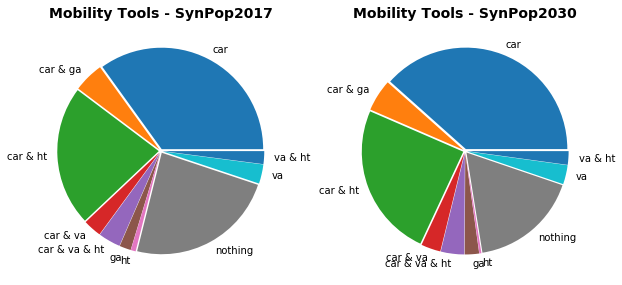

In [17]:
plt.figure(figsize=(10, 20))

explode = [0.02] * mobility.shape[0]

ax = plt.subplot(1,2,1)
ax = mobility['SynPop{}_pp'.format(YEAR_IST)].sort_index().plot.pie(explode=explode, ax=ax)
_ = ax.set_title('Mobility Tools - SynPop{}'.format(YEAR_IST), fontdict={'fontsize': 14, 'fontweight': 'bold'})
_ = plt.ylabel('')

ax = plt.subplot(1,2,2)
ax = mobility['SynPop{}_pp'.format(YEAR)].sort_index().plot.pie(explode=explode, ax=ax)
_ = ax.set_title('Mobility Tools - SynPop{}'.format(YEAR), fontdict={'fontsize': 14, 'fontweight': 'bold'})
_ = plt.ylabel('')

if SAVE_FIGURES:
    fig_file_name = '02-01_SynPop{}_vs_SynPop{}_mobility_tools_pie_plots.{}'.format(YEAR_IST, YEAR, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### Avaiable Mobility Tools

In [18]:
df1 = (persons_ist[['has_ga', 'has_ht', 'has_va', 'car_available']].sum()).rename('SynPop{}'.format(YEAR_IST))
df2 = (persons[['has_ga', 'has_ht', 'has_va', 'car_available']].sum()).rename('SynPop{}'.format(YEAR))
    
mobility_tools = pd.merge(df1, df2, left_index=True, right_index=True)

mobility_tools['SynPop{}_pp'.format(YEAR_IST)] = mobility_tools['SynPop{}'.format(YEAR_IST)] / len(persons_ist)
mobility_tools['SynPop{}_pp'.format(YEAR)] = mobility_tools['SynPop{}'.format(YEAR)] / len(persons)

mobility_tools.index = ['ga', 'ht', 'va', 'cars']

In [19]:
mobility_tools

,SynPop2017,SynPop2030,SynPop2017_pp,SynPop2030_pp
ga,567094,703989,0.066248,0.073660
ht,2455202,2943780,0.286818,0.308016
va,991684,1155215,0.115849,0.120873
cars,5862948,7160073,0.684912,0.749179


2020-02-18 10:06:32,385 - INFO - root: Figure saved to file : ./outputs\02-02_SynPop2030_vs_SynPop2017_mobility_tools_absolute_numbers.png


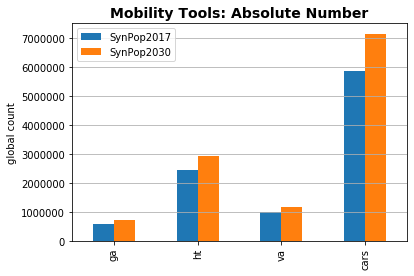

In [20]:
ax = mobility_tools[['SynPop{}'.format(YEAR_IST), 'SynPop{}'.format(YEAR)]].plot.bar()
ax.grid(axis='y')
_ = plt.ylabel('global count')
title = 'Mobility Tools: Absolute Number'
_ = ax.set_title(title, fontdict={'fontsize': 14, 'fontweight': 'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-02_SynPop{}_vs_SynPop{}_mobility_tools_absolute_numbers.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

2020-02-18 10:06:32,827 - INFO - root: Figure saved to file : ./outputs\02-03_SynPop2030_vs_SynPop2017_mobility_tools_per_person_averages.png


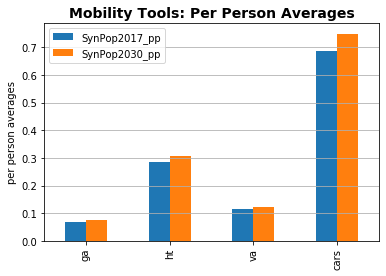

In [21]:
ax = mobility_tools[['SynPop{}_pp'.format(YEAR_IST), 'SynPop{}_pp'.format(YEAR)]].plot.bar()
ax.grid(axis='y')
_ = plt.ylabel('per person averages')
title = 'Mobility Tools: Per Person Averages'
_ = ax.set_title(title, fontdict={'fontsize': 14, 'fontweight': 'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-03_SynPop{}_vs_SynPop{}_mobility_tools_per_person_averages.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

### Evolution By Canton 

In [22]:
mobility_tools_per_canton_ist = (persons_ist.groupby('KT_full')
                                              .agg({'has_ga':sum, 
                                                    'has_ht':sum, 
                                                    'has_va':sum, 
                                                    'car_available':sum, 
                                                    'person_id':'count'})
                                              .astype(int)
                                              .rename(columns={'person_id': 'pop'})
                                 )
mobility_tools_per_canton = (persons.groupby('KT_full')
                                         .agg({'has_ga':sum, 
                                                    'has_ht':sum, 
                                                    'has_va':sum, 
                                                    'car_available':sum, 
                                                    'person_id':'count'})
                                         .astype(int)
                                         .rename(columns={'person_id': 'pop'})
                                 )

cols = ['has_ga', 'has_ht', 'has_va', 'car_available', 'pop']

delta_mobility_tools_abs = mobility_tools_per_canton[cols] - mobility_tools_per_canton_ist[cols]
delta_mobility_tools_abs.columns = ['delta_ga', 'delta_ht', 'delta_va', 'delta_car', 'delta_pop']

delta_mobility_tools_rel = delta_mobility_tools_abs.apply(lambda s: s / mobility_tools_per_canton_ist['pop'])
delta_mobility_tools_rel.columns = ['delta_rel_ga', 'delta_rel_ht', 'delta_rel_va', 'delta_rel_car', 'delta_rel_pop']

In [23]:
delta_mobility_tools_abs

,delta_ga,delta_ht,delta_va,delta_car,delta_pop
KT_full,,,,,
Aargau,13853,46961,7356,126520,103055
Appenzell Ausserrhoden,181,1243,1018,3984,-2689
Appenzell Innerrhoden,51,204,-828,1110,-932
Basel-Landschaft,2813,14703,1073,44474,20210
Basel-Stadt,2962,7489,3902,14315,-9862
Bern / Berne,27774,62539,18922,132634,122526
Fribourg / Freiburg,4475,15259,5151,61280,71719
Genève,2101,16547,-2962,78604,48106
Glarus,390,693,238,4041,-340


**Visualisations**

In [24]:
default_map_client  = SwissZoneMap(outline_cantons=True, draw_lakes=True)

In [25]:
def round_up(x):
    return int(math.ceil(x / 1000.0)) * 1000

#### Population Evolution 

In [26]:
delta_mobility_tools_abs['delta_pop'].agg([sum, min, max])

sum    997081
min     -9862
max    213740
Name: delta_pop, dtype: int64

2020-02-18 10:06:36,850 - INFO - root: Figure saved to file : ./outputs\02-04_SynPop2030_vs_SynPop2017_mobility_tools_population_evolution.png


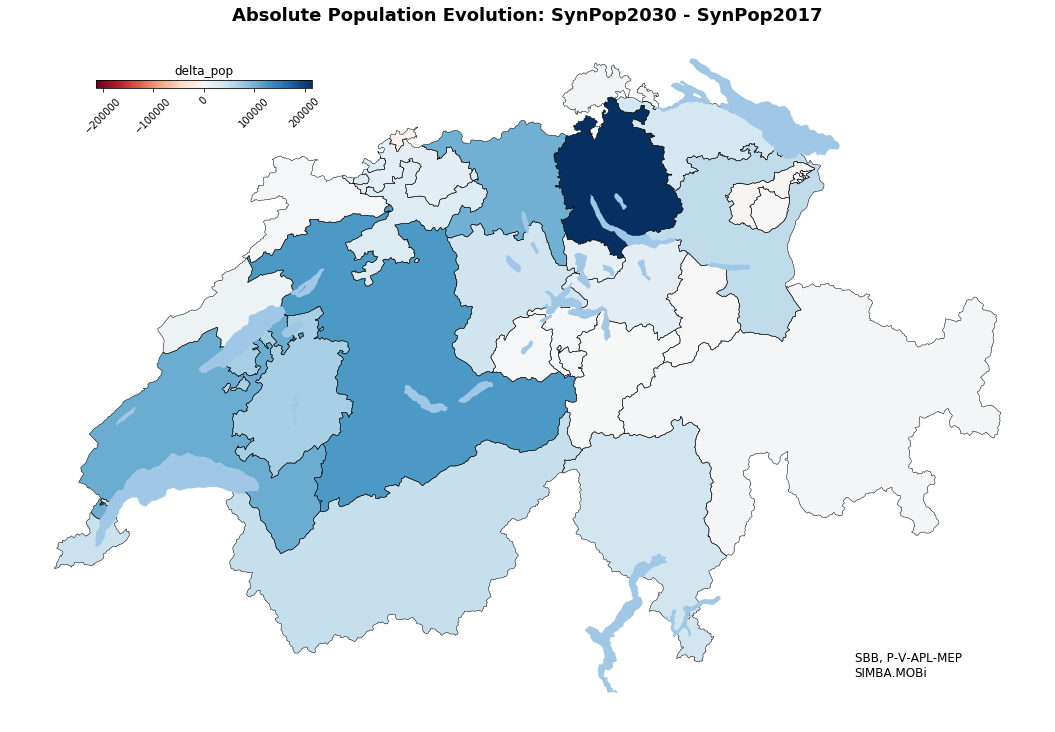

In [27]:
scale_bound = round_up(delta_mobility_tools_abs['delta_pop'].abs().max())
ax = default_map_client.draw_cantons(delta_mobility_tools_abs, column='delta_pop', vmin=-scale_bound, vmax=scale_bound)
title = 'Absolute Population Evolution: SynPop{} - SynPop{}'.format(YEAR, YEAR_IST)
_ = ax.set_title(title, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-04_SynPop{}_vs_SynPop{}_mobility_tools_population_evolution.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### GA Evolution

In [28]:
delta_mobility_tools_abs['delta_ga'].agg([sum, min, max])

sum    136895
min        51
max     31954
Name: delta_ga, dtype: int64

2020-02-18 10:06:38,060 - INFO - root: Figure saved to file : ./outputs\02-05_SynPop2030_vs_SynPop2017_mobility_tools_GA_evolution.png


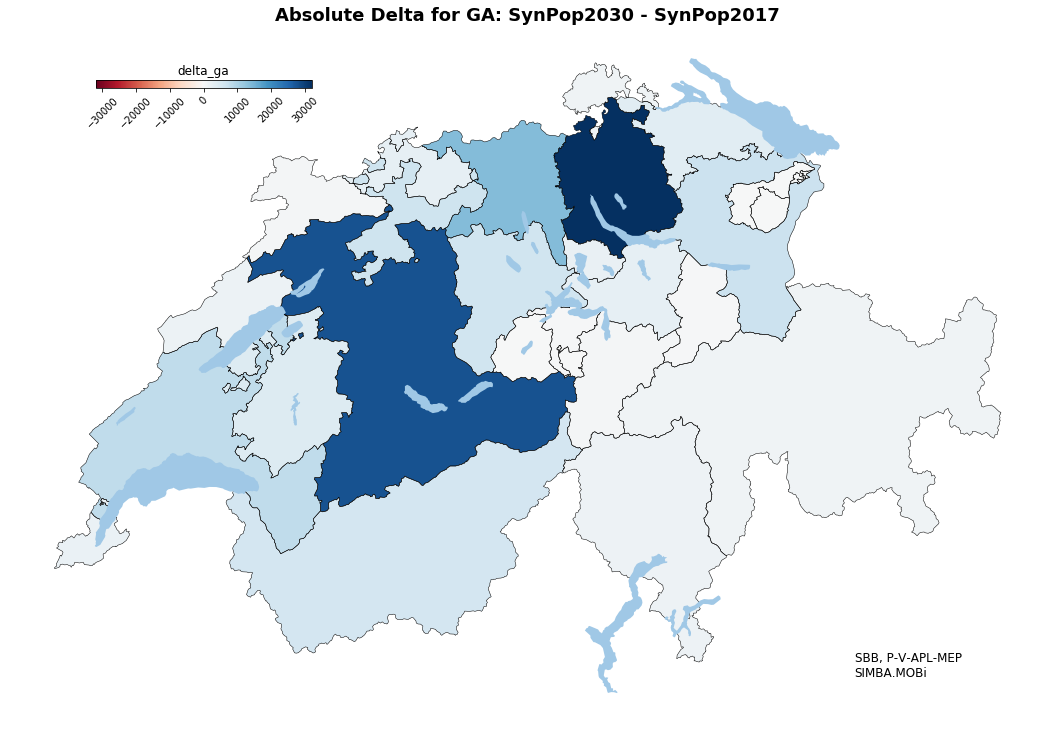

In [29]:
scale_bound = round_up(delta_mobility_tools_abs['delta_ga'].abs().max())
ax = default_map_client.draw_cantons(delta_mobility_tools_abs, column='delta_ga', vmin=-scale_bound, vmax=scale_bound)
title = 'Absolute Delta for GA: SynPop{} - SynPop{}'.format(YEAR, YEAR_IST)
_ = ax.set_title(title, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-05_SynPop{}_vs_SynPop{}_mobility_tools_GA_evolution.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### HT Evolution

In [30]:
delta_mobility_tools_abs['delta_ht'].agg([sum, min, max])

sum    488578
min       204
max    134600
Name: delta_ht, dtype: int64

2020-02-18 10:06:39,331 - INFO - root: Figure saved to file : ./outputs\02-06_SynPop2030_vs_SynPop2017_mobility_tools_HT_evolution.png


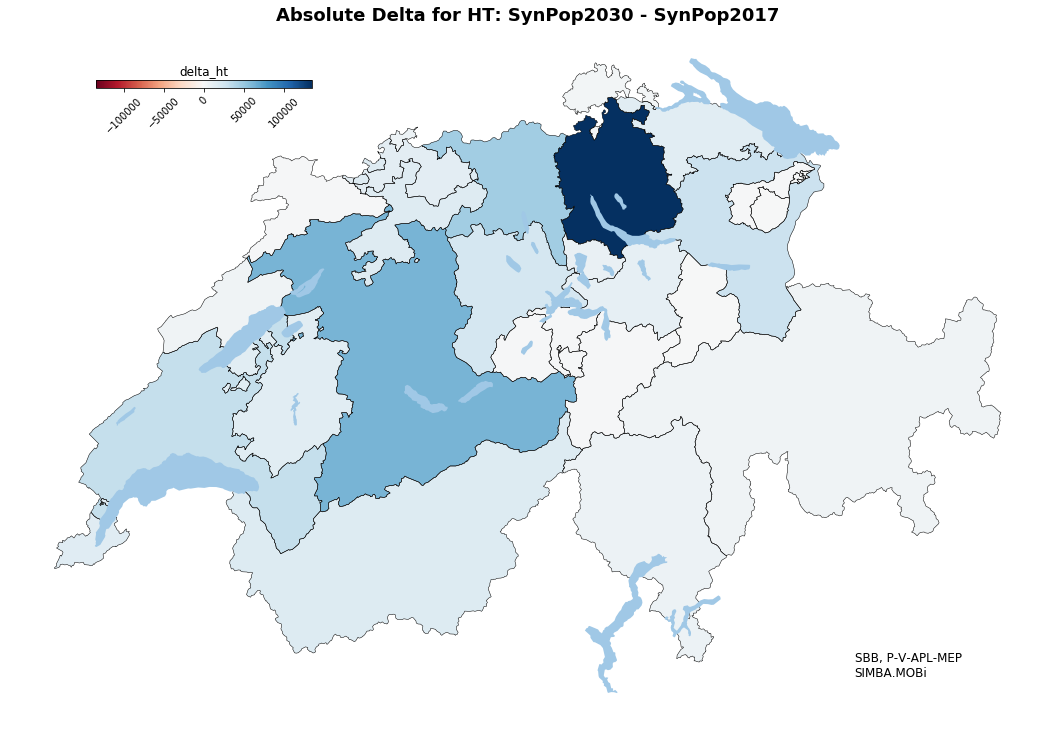

In [31]:
scale_bound = round_up(delta_mobility_tools_abs['delta_ht'].abs().max())
ax = default_map_client.draw_cantons(delta_mobility_tools_abs, column='delta_ht', vmin=-scale_bound, vmax=scale_bound)
title = 'Absolute Delta for HT: SynPop{} - SynPop{}'.format(YEAR, YEAR_IST)
_ = ax.set_title(title, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-06_SynPop{}_vs_SynPop{}_mobility_tools_HT_evolution.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### VA Evolution

In [32]:
delta_mobility_tools_abs['delta_va'].agg([sum, min, max])

sum    163531
min     -2962
max     64316
Name: delta_va, dtype: int64

2020-02-18 10:06:40,454 - INFO - root: Figure saved to file : ./outputs\02-07_SynPop2030_vs_SynPop2017_mobility_tools_VA_evolution.png


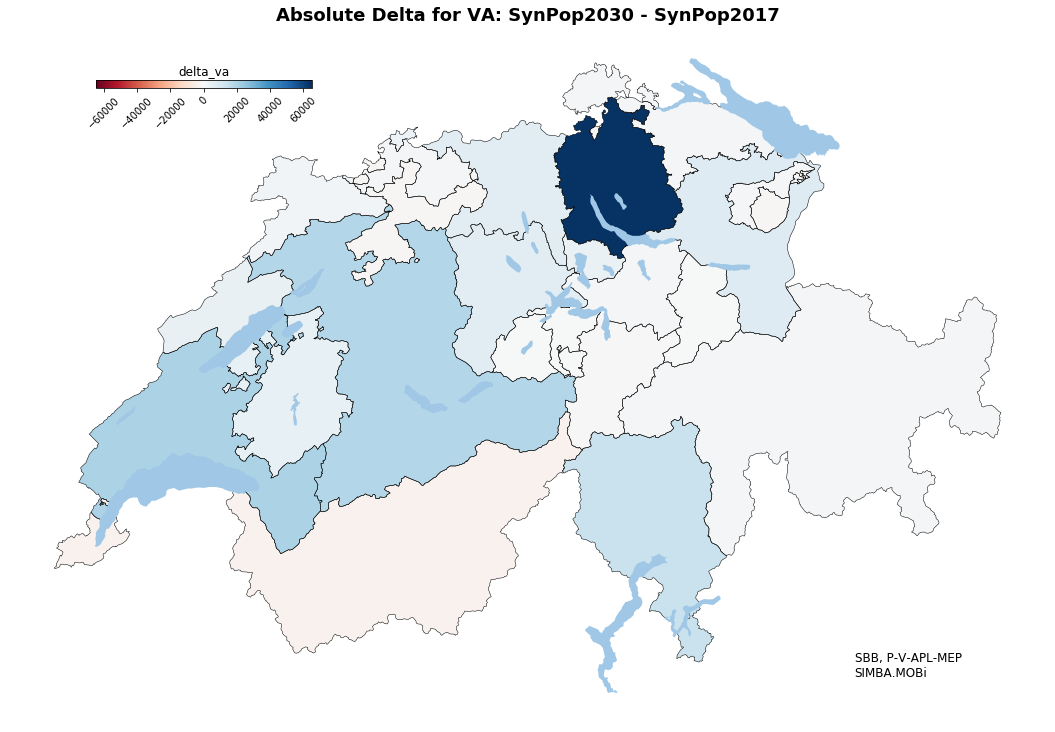

In [33]:
scale_bound = round_up(delta_mobility_tools_abs['delta_va'].abs().max())
ax = default_map_client.draw_cantons(delta_mobility_tools_abs, column='delta_va', vmin=-scale_bound, vmax=scale_bound)
title = 'Absolute Delta for VA: SynPop{} - SynPop{}'.format(YEAR, YEAR_IST)
_ = ax.set_title(title, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-07_SynPop{}_vs_SynPop{}_mobility_tools_VA_evolution.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

#### Cars Evolution

In [34]:
delta_mobility_tools_abs['delta_car'].agg([sum, min, max])

sum    1297125
min       1110
max     242862
Name: delta_car, dtype: int64

2020-02-18 10:06:41,596 - INFO - root: Figure saved to file : ./outputs\02-08_SynPop2030_vs_SynPop2017_mobility_tools_CARS_evolution.png


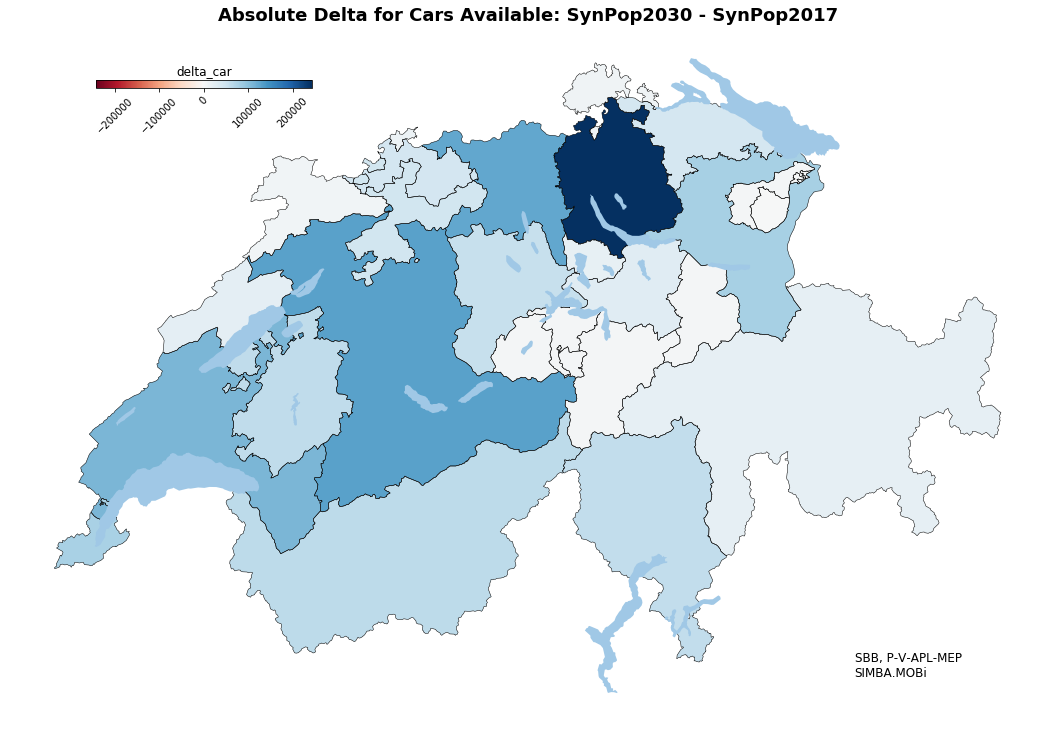

In [35]:
scale_bound = round_up(delta_mobility_tools_abs['delta_car'].abs().max())
ax = default_map_client.draw_cantons(delta_mobility_tools_abs, column='delta_car', vmin=-scale_bound, vmax=scale_bound)
title = 'Absolute Delta for Cars Available: SynPop{} - SynPop{}'.format(YEAR, YEAR_IST)
_ = ax.set_title(title, fontdict={'fontsize':18, 'fontweight':'bold'})

if SAVE_FIGURES:
    fig_file_name = '02-08_SynPop{}_vs_SynPop{}_mobility_tools_CARS_evolution.{}'.format(YEAR, YEAR_IST, FIG_FORMAT)
    fig_file_path = os.path.join(OUTPUT_DIR, fig_file_name)
    plt.savefig(fig_file_path, dpi=FIG_DPI, format=FIG_FORMAT, bbox_inches=FIG_BBOX_INCHES, pad_inches=FIG_PAD_INCHES)
    logging.info('Figure saved to file : {}'.format(fig_file_path))

## Export Notebook to HTML

In [36]:
### Write notebook to a html file
!jupyter nbconvert --to html 02_Mobility_Tools.ipynb

[NbConvertApp] Converting notebook 02_Mobility_Tools.ipynb to html
[NbConvertApp] Writing 1491713 bytes to 02_Mobility_Tools.html
